# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

In [ ]:
# Importamos las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cargamos el dataset car_crashes

In [ ]:
# Cargamos y guardamos el dataset en una variable
df_car_crashes = sns.load_dataset('car_crashes')
df_car_crashes.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [ ]:
# Mostramos las propiedades de la tabla
df_car_crashes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total           51 non-null     float64
 1   speeding        51 non-null     float64
 2   alcohol         51 non-null     float64
 3   not_distracted  51 non-null     float64
 4   no_previous     51 non-null     float64
 5   ins_premium     51 non-null     float64
 6   ins_losses      51 non-null     float64
 7   abbrev          51 non-null     object 
dtypes: float64(7), object(1)
memory usage: 3.3+ KB


In [ ]:
# Mostramos un resumen estadístico
df_car_crashes.describe()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,15.790196,4.998196,4.886784,13.573176,14.004882,886.957647,134.493137
std,4.122002,2.017747,1.729133,4.508977,3.764672,178.296285,24.835922
min,5.900000,1.792000,1.593000,1.760000,5.900000,641.960000,82.750000
25%,12.750000,3.766500,3.894000,10.478000,11.348000,768.430000,114.645000
50%,15.600000,4.608000,4.554000,13.857000,13.775000,858.970000,136.050000
75%,18.500000,6.439000,5.604000,16.140000,16.755000,1007.945000,151.870000
max,23.900000,9.450000,10.038000,23.661000,21.280000,1301.520000,194.780000


Obtenemos medidas de tendencia central para la columna "total"

In [ ]:
# Definimos las medidas de tendencia central
media_total = round(df_car_crashes['total'].mean(), 2)
mediana_total = round(df_car_crashes['total'].median(), 2)
moda_total = df_car_crashes['total'].mode()[0]

In [ ]:
# Definimos las medidas de dispersión
std_total = round(df_car_crashes['total'].std(), 2)
percentil_total = np.percentile(df_car_crashes['total'], [25, 50, 75])

q_1_total = round(percentil_total[0], 2)
q_3_total = round(percentil_total[2], 2)
iqr_total = q_3_total - q_1_total

In [ ]:
# Definir variables
x = range(len(df_car_crashes['total']))
y = df_car_crashes['total']

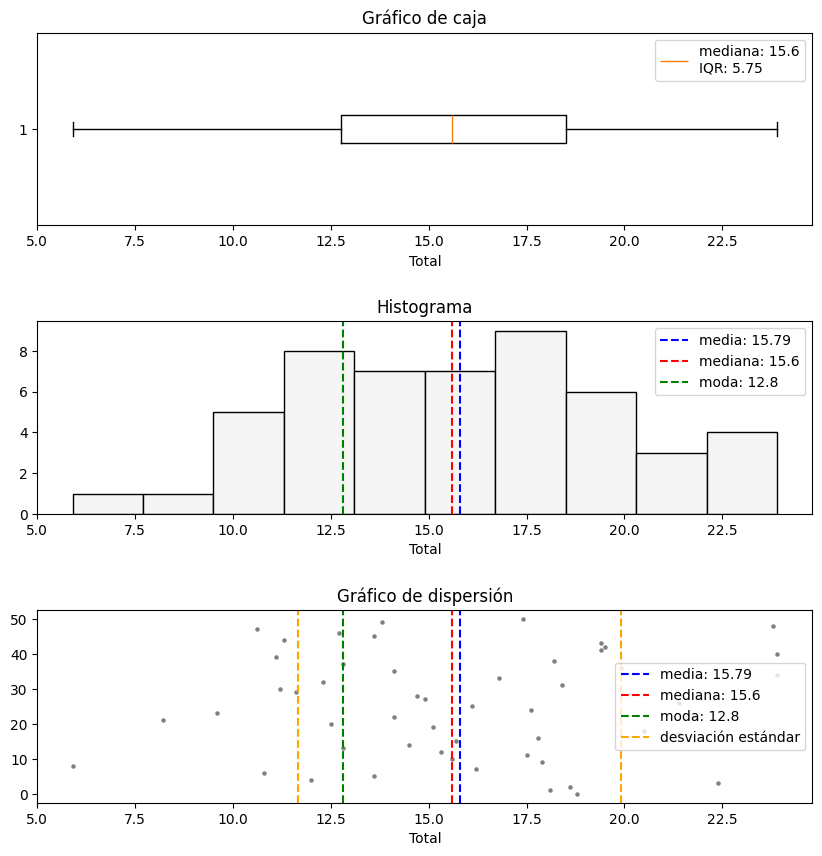

In [ ]:
# Visualizar medidas descriptivas
fig, ax = plt.subplots(3, figsize = (10, 10), gridspec_kw = {'hspace': 0.5})

ax[0].boxplot(df_car_crashes['total'], vert = False, label = f'mediana: {mediana_total}\nIQR: {iqr_total}')
ax[0].set_title('Gráfico de caja')
ax[0].set_xlabel('Total')
ax[0].legend(loc = 'upper right')

ax[1].hist(df_car_crashes['total'], edgecolor = 'black', color = 'whitesmoke')
ax[1].axvline(x = media_total, color = 'blue', linestyle = '--', label = f'media: {media_total}')
ax[1].axvline(x = mediana_total, color = 'red', linestyle = '--',label = f'mediana: {mediana_total}')
ax[1].axvline(x = moda_total, color = 'green', linestyle = '--', label = f'moda: {moda_total}')
ax[1].set_title('Histograma')
ax[1].set_xlabel('Total')
ax[1].legend(loc = 'upper right')

ax[2].scatter(y, x, color = 'gray', s = 5)
ax[2].axvline(x = media_total, color = 'blue', linestyle = '--', label = f'media: {media_total}')
ax[2].axvline(x = mediana_total, color = 'red', linestyle = '--', label = f'mediana: {mediana_total}')
ax[2].axvline(x = moda_total, color = 'green', linestyle = '--', label = f'moda: {moda_total}')
ax[2].axvline(x = media_total + std_total, color = 'orange', linestyle = '--', label = f'desviación estándar')
ax[2].axvline(x = media_total - std_total, color = 'orange', linestyle = '--')
ax[2].set_title('Gráfico de dispersión')
ax[2].set_xlabel('Total')
ax[2].legend(loc = 'center right')

plt.show()


Realizamos un análisis multivariable:

In [ ]:
# Definir variables
columnas = ['speeding', 'alcohol', 'not_distracted', 'no_previous', 'ins_premium', 'ins_losses', 'total' ]
correlacion = df_car_crashes[columnas].corr()
long_col = len(columnas)
corr_inv = correlacion.iloc[::-1]

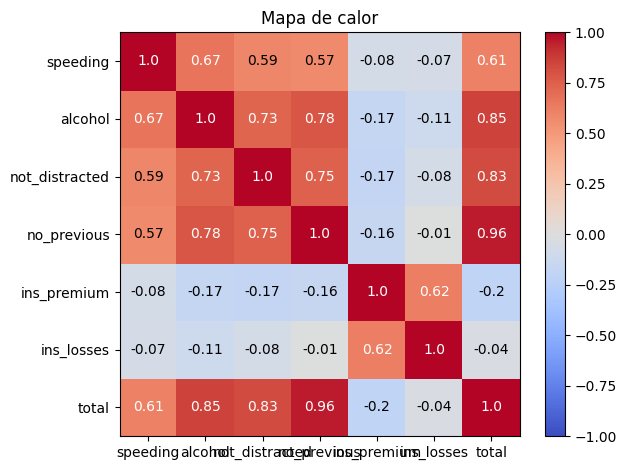

In [ ]:
# Visualizar mapa de calor
heatmap = plt.pcolor(corr_inv, cmap = 'coolwarm', vmin = -1, vmax = 1)

plt.title('Mapa de calor')
plt.xticks(np.arange(0.5, long_col, 1), columnas)
plt.yticks(np.arange(0.5, long_col, 1), columnas[::-1])

for i in range(long_col):
    for j in range(long_col):
        val = round(corr_inv.iloc[i, j], 2)
        plt.text(j + 0.5, i + 0.5, f'{val}',
                 ha = 'center', va = 'center',
                 color = 'white' if abs(val) > 0.6 else 'black')

plt.colorbar(heatmap)
plt.tight_layout()
plt.show()

Realizamos un análisis bivariable

In [ ]:
# Calculamos los coefecientes de correlación de Pearson de las tres correlaciones más fuertes que ibtuvimos del heatmap

corr_total_no_previous = round(df_car_crashes['total'].corr(df_car_crashes['no_previous']), 2)
corr_total_not_distracted = round(df_car_crashes['total'].corr(df_car_crashes['not_distracted']), 2)
corr_total_alcohol = round(df_car_crashes['total'].corr(df_car_crashes['alcohol']), 2)

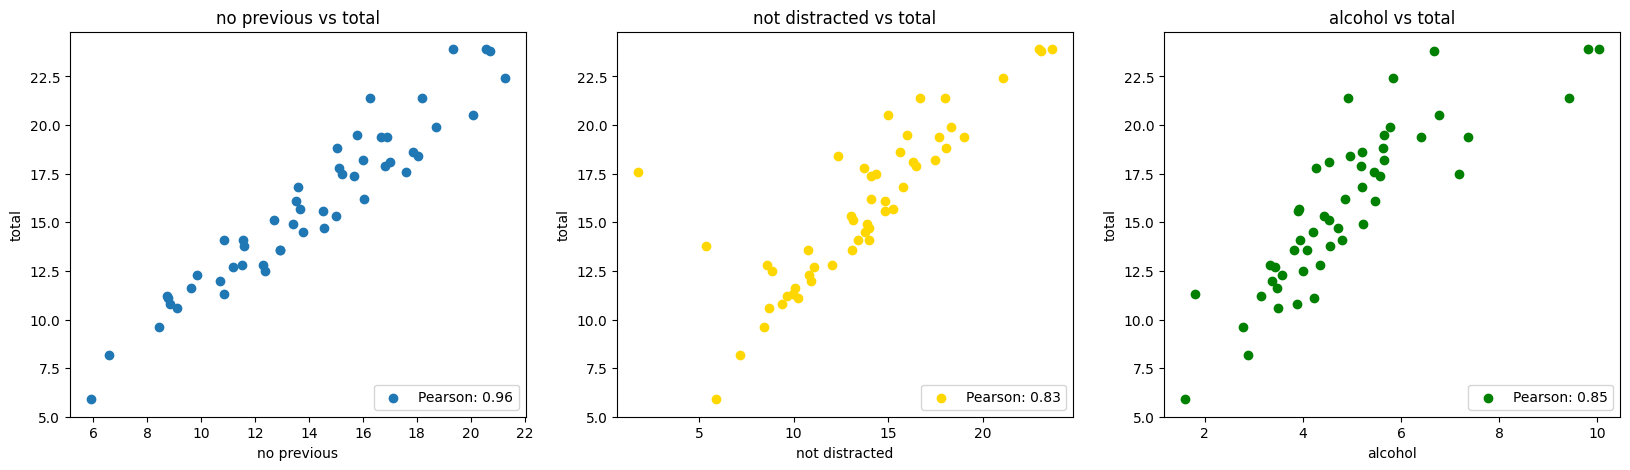

In [ ]:
# Visualizar correlaciones

fig, ax = plt.subplots(1, 3, figsize = (20, 5), gridspec_kw = {'hspace': 0.5})

ax[0].scatter(data = df_car_crashes, x = 'no_previous', y = 'total', label = f'Pearson: {corr_total_no_previous}')
ax[0].set_title('no previous vs total')
ax[0].set_ylabel('total')
ax[0].set_xlabel('no previous')
ax[0].legend(loc = 'lower right')

ax[1].scatter(data = df_car_crashes, x = 'not_distracted', y = 'total', color = 'gold', label = f'Pearson: {corr_total_not_distracted}')
ax[1].set_title('not distracted vs total')
ax[1].set_ylabel('total')
ax[1].set_xlabel('not distracted')
ax[1].legend(loc = 'lower right')

ax[2].scatter(data = df_car_crashes, x = 'alcohol', y = 'total', color = 'green', label = f'Pearson: {corr_total_alcohol}')
ax[2].set_title('alcohol vs total')
ax[2].set_ylabel('total')
ax[2].set_xlabel('alcohol')
ax[2].legend(loc = 'lower right')

plt.show()

Realizamos una prueba de hipótesis

In [ ]:
# Importar módulo

from scipy import stats

Para nuestra prueba de hipótesis, generaremos dos grupos: Los estados que más consumen alcohol y los que menos lo hacen. Para separar los grupos de la columna 'alcohol' utilizamos la mediana, ya que es menos sensible a outliers.

H_0 = El costo promedio del seguro (ins_premium) es igual en ambos grupos.

H_1 = El costo promedio del seguro (ins_premium) es diferente en ambos grupos.

In [ ]:
# Creamos los dos grupos basados en la mediana de alcohol

mediana_alcohol = df_car_crashes['alcohol'].median()

grupo_alto = df_car_crashes[df_car_crashes['alcohol'] > mediana_alcohol]['ins_premium']
grupo_bajo = df_car_crashes[df_car_crashes['alcohol'] <= mediana_alcohol]['ins_premium']

In [ ]:
# Aplicar Prueba T de Student

t_stats_alcohol, p_value_alcohol = stats.ttest_ind(grupo_alto, grupo_bajo)

print(f"P-Value: {p_value_alcohol:.4f}")

P-Value: 0.7011


In [ ]:
# Interpretación automática

if p_value_alcohol < 0.01:
  print("\nConclusión: Rechazamos la Hipótesis Nula.")
  print("Existe una diferencia muy significativa entre el costo promedio del seguro para ambos grupos de consumo de alcohol.")

elif 0.01 <= p_value_alcohol < 0.05:
  # 0.01 <= p_value_color < 0.05
  print("\nConclusión: Rechazamos la Hipótesis Nula.")
  print("Existe una diferencia altamente significativa entre el costo promedio del seguro para ambos grupos de consumo de alcohol.")

elif 0.05 <= p_value_alcohol < 0.10:
  print("\nConclusión: Rechazamos la Hipótesis Nula.")
  print("Existe una diferencia moderadamente significativa entre el costo promedio del seguro para ambos grupos de consumo de alcohol.")

else:
  print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
  print("No hay evidencia suficiente para decir que el costo promedio del seguro es diferente para ambos grupos de consumo de alcohol.")


Conclusión: No podemos rechazar la Hipótesis Nula.
No hay evidencia suficiente para decir que el costo promedio del seguro es diferente para ambos grupos de consumo de alcohol.


Aprendizaje estadístico: Creamos un modelo de regresión lineal para predecir cuántas unidades aumenta el total de accidentes cada que aumenta el consumo de alcohol.

In [ ]:
# Definir variables

x_alcohol = df_car_crashes['alcohol']
y_total_accidentes = df_car_crashes['total']
n = len(x)

In [ ]:
# Definir regresión lineal

beta_, alpha_ = np.polyfit(x_alcohol, y_total_accidentes, 1)
print(f'y = {round(beta_, 2)}x + {round(alpha_, 2)}')

y = 2.03x + 5.86


In [ ]:
# Definir Parámetros
tamaño_paso_taxis = 0.017 #prueba
theta_0_ = 0
theta_1_ = 0

# Realizar algoritmo del descenso de gradiente
iteraciones = 100
perdida = []

for i in range(iteraciones):

  y_prediccion = theta_1_ * x_alcohol + theta_0_
  error = ((y_prediccion - y_total_accidentes) ** 2).mean()
  perdida.append(error)

  d_theta_0_ = 2*(y_prediccion - y_total_accidentes).mean()
  d_theta_1_ = 2*((y_prediccion - y_total_accidentes) * x_alcohol).mean()

  theta_0_ = theta_0_ - tamaño_paso_taxis * d_theta_0_
  theta_1_ = theta_1_ - tamaño_paso_taxis * d_theta_1_

print(f'y = {round(theta_1_, 2)}x + {round(theta_0_, 2)}')

y = 2.71x + 2.16


In [ ]:
# Predicción de valores con descenso de gradiente
distancia_gradiente = float(input('Ingresa el total de alcohol: ')) #Valor entre 1 a 10 según el mínimo y el máximo
costo_gradiente = round(theta_1_ * distancia_gradiente + theta_0_, 2)

print(f'El total de accidentes será de: {costo_gradiente}')

Ingresa el total de alcohol: 5
El total de accidentes será de: 15.71


Visualizamos las regresiones

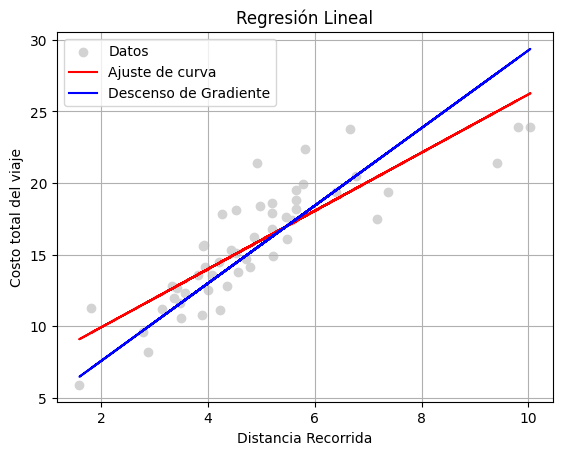

In [ ]:
# Visualizar regresiones
plt.scatter(x_alcohol, y_total_accidentes, color = 'lightgray', label = 'Datos')
plt.plot(x_alcohol, beta_* x_alcohol + alpha_, color = 'red', label = 'Ajuste de curva')
plt.plot(x_alcohol, theta_1_* x_alcohol + theta_0_, color = 'blue', label = 'Descenso de Gradiente')
plt.title('Regresión Lineal')
plt.xlabel('Distancia Recorrida')
plt.ylabel('Costo total del viaje')
plt.legend(loc = 'upper left')
plt.grid()
plt.show()

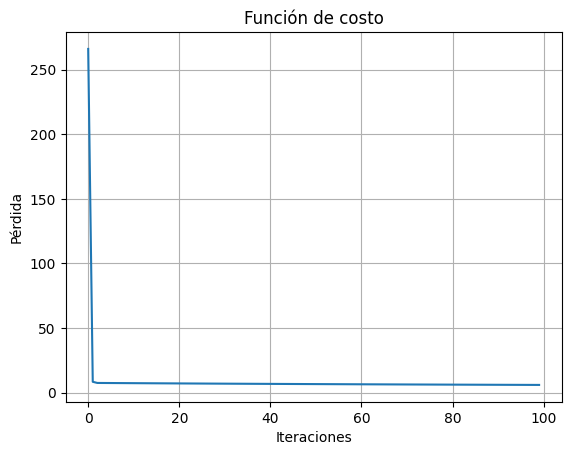

In [ ]:
# Visualizamos la función de costo
plt.plot(perdida, label = 'Errores')
plt.title('Función de costo')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.grid()
plt.show()